In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

In [2]:
dp_samples = fits.open('dp_sample_catalog.fits')
dp_samples.info()

Filename: dp_sample_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  DATA          1 BinTableHDU     53   1308R x 22C   [K, E, E, E, E, E, E, E, E, E, E, E, L, L, L, L, L, L, L, L, L, L]   
  2  1COMP         1 ImageHDU         8   (7781, 1308)   float32   
  3  2COMP_L       1 ImageHDU         8   (7781, 1308)   float32   
  4  2COMP_R       1 ImageHDU         8   (7781, 1308)   float32   


In [3]:
samples_df = Table(dp_samples[1].data).to_pandas()

In [4]:
DP = DP()
# DP.record_ids(df = samples_df, fname='dp_samples_ids_test.txt')

In [5]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

FIT = FitSpectrum()
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=samples_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()
DP_SPECTRA = FIT.label_emission_lines(DP_SPECTRA, 5)

In [6]:
model_1comp = dp_samples[2].data
model_2comp_l = dp_samples[3].data
model_2comp_r = dp_samples[4].data

In [56]:
test_idx = np.random.choice(len(samples_df), size=1, replace=False)[0]
# test_id = 39627794254137309
# test_idx = samples_df.index[samples_df['id'] == test_id].tolist()[0]
test_1comp = model_1comp[test_idx]
test_2comp_l = model_2comp_l[test_idx]
test_2comp_r = model_2comp_r[test_idx]
test_2comp = test_2comp_l + test_2comp_r


lam, flux, ivar = DP_SPECTRA.data_stack[test_idx, 0, :], DP_SPECTRA.data_stack[test_idx, 1, :], DP_SPECTRA.data_stack[test_idx, 2, :]
emission = DP_SPECTRA.data_stack[test_idx, 5, :]
sigma = 1/np.sqrt(np.abs(ivar))

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_18708/581483155.py:12: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [57]:
samples_df.iloc[test_idx]

TARGETID       39627788117870255
RA                    202.074509
DEC                     0.018202
Z                       0.170708
LOGM                   11.051802
LOGSFR                 -2.796699
dv_r                    6.261431
dv_l                 -166.076614
sigma_r               153.533936
sigma_l                 5.847595
sigma_1comp           168.026352
p_value                      0.0
OII3726_dp                 False
OII3729_dp                 False
Hbeta_dp                   False
OIII4959_dp                False
OIII5007_dp                 True
NII6548_dp                 False
Halpha_dp                  False
NII6583_dp                 False
SII6716_dp                 False
SII6731_dp                 False
Name: 787, dtype: object

In [58]:
print(samples_df.iloc[test_idx]['p_value'])

1.1903434e-10


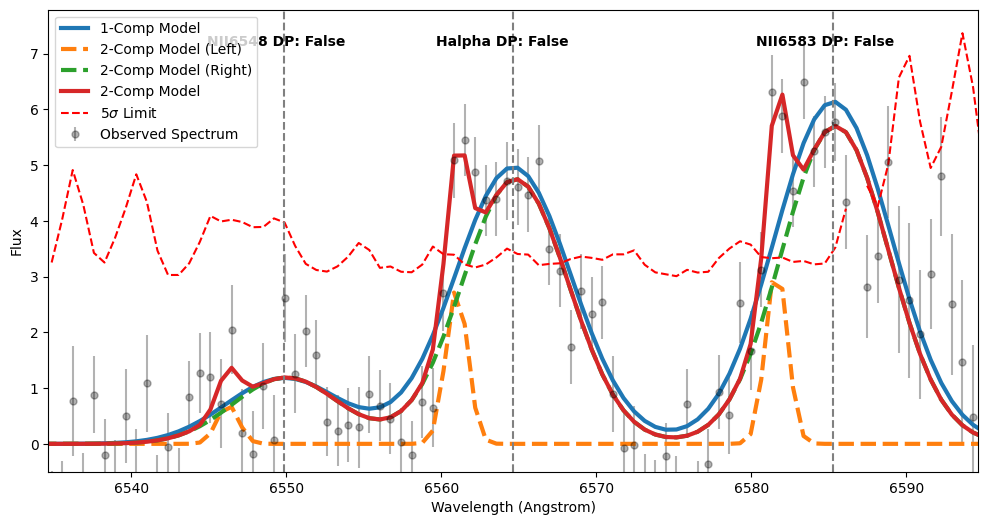

In [59]:
line_cols = ['OII3726', 'OII3729',
            'Hbeta',
            'OIII4959', 'OIII5007',
            'NII6548', 'Halpha', 'NII6583',
            'SII6716', 'SII6731']
lines = [*OII_rest, *Hbeta_rest, *OIII_rest, NII_rest[0], *Halpha_rest, NII_rest[1], *SII_rest]

plt.figure(figsize=(12,6))
plt.errorbar(lam, flux, yerr=sigma, label='Observed Spectrum', fmt='o', color='k', markersize=5, alpha=0.3)
plt.plot(lam, test_1comp, label='1-Comp Model', linewidth=3)
plt.plot(lam, test_2comp_l, label='2-Comp Model (Left)', linestyle='--', linewidth=3)
plt.plot(lam, test_2comp_r, label='2-Comp Model (Right)', linestyle='--', linewidth=3)
plt.plot(lam, test_2comp, label='2-Comp Model', linewidth=3)
# plt.plot(lam, emission, label='Emission Line Only', color='orange', alpha=0.7)
plt.plot(lam, 5*sigma, label=r'5$\sigma$ Limit', color='red', linestyle='--')
# plt.text(6550, 10, 'test', rotation=90, color='gray', fontsize=8)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.xlim([Halpha_rest[0]-30, Halpha_rest[0]+30])
# plt.xlim([OII_rest[0]-30, OII_rest[1]+30])
# plt.xlim([Hbeta_rest[0]-30, Hbeta_rest[0]+30])
# plt.xlim([OIII_rest[0]-30, OIII_rest[1]+30])
plt.ylim(bottom=-0.5, top=np.max(flux[(lam>plt.xlim()[0]) & (lam<plt.xlim()[1])])*1.2)

for i, line in enumerate(lines):
    if line < plt.xlim()[0] or line > plt.xlim()[1]:
        continue
    else:
        plt.axvline(x=line, color='gray', linestyle='--')
        line_label = f'{line_cols[i]} DP: {samples_df[line_cols[i]+'_dp'].iloc[test_idx]}'
        plt.text(line-5, np.max(flux[(lam>plt.xlim()[0]) & (lam<plt.xlim()[1])])*1.1, line_label, color='k', fontsize=10, weight='bold')
plt.legend()
plt.show()